# Text Classifier Project

The objective of this project is to train a model that automatically detects negative film reviews. Conduct training on three different models as well of composing personally written reviews to test model funcionality. Model must reach an F1 score of 0.85.

**Models evaluated:** LogisticRegression, LightGBM, NLTK, SPACY, TF-IDF, BERT

**Evaluation metrics:** F1 score, accuracy, precision. ROC-AUC

## Initialization

In [1]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [2]:
import math

import numpy as np
import pandas as pd
import nltk
import spacy
import torch
import transformers
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMClassifier
from lightgbm.callback import log_evaluation

nltk.download('stopwords')
from nltk.corpus import stopwords as nltk_stopwords
nltk.download('punkt')
from nltk.tokenize import word_tokenize
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sklearn.metrics as metrics
import seaborn as sns

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\danco\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\danco\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\danco\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn-v0_8')

In [4]:
# Use to track training progress
tqdm.pandas()

## Load Data

In [5]:
df_reviews = pd.read_csv('imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [6]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

## EDA

Let's check the number of movies and reviews over years.

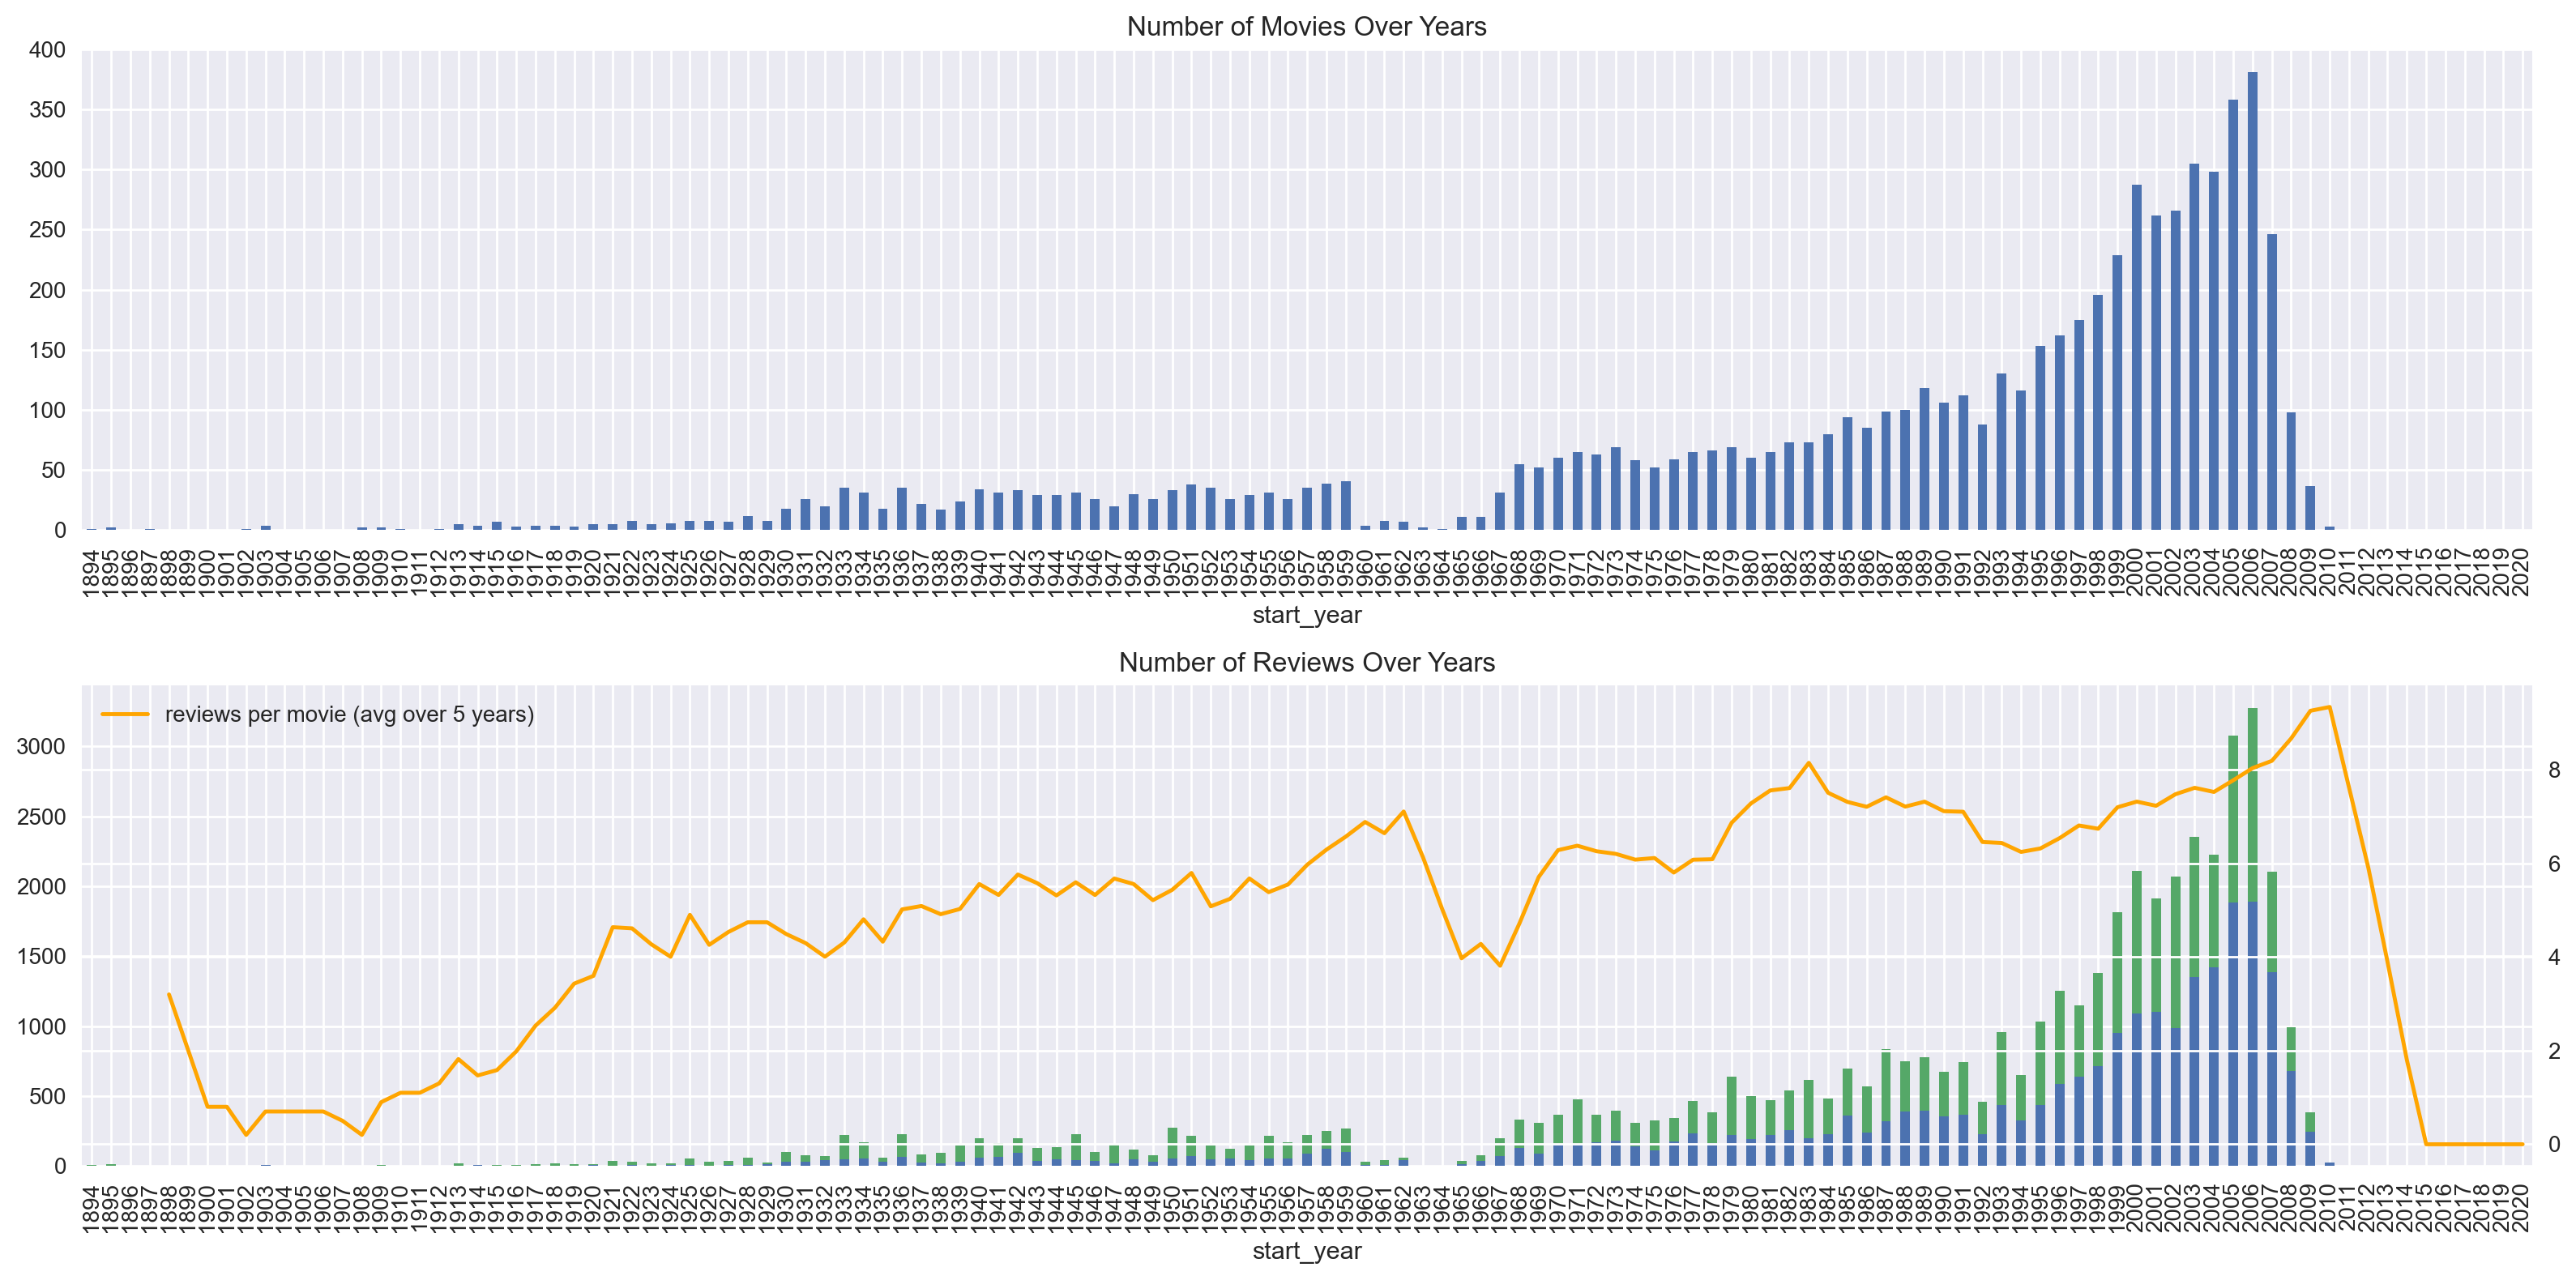

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Check distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

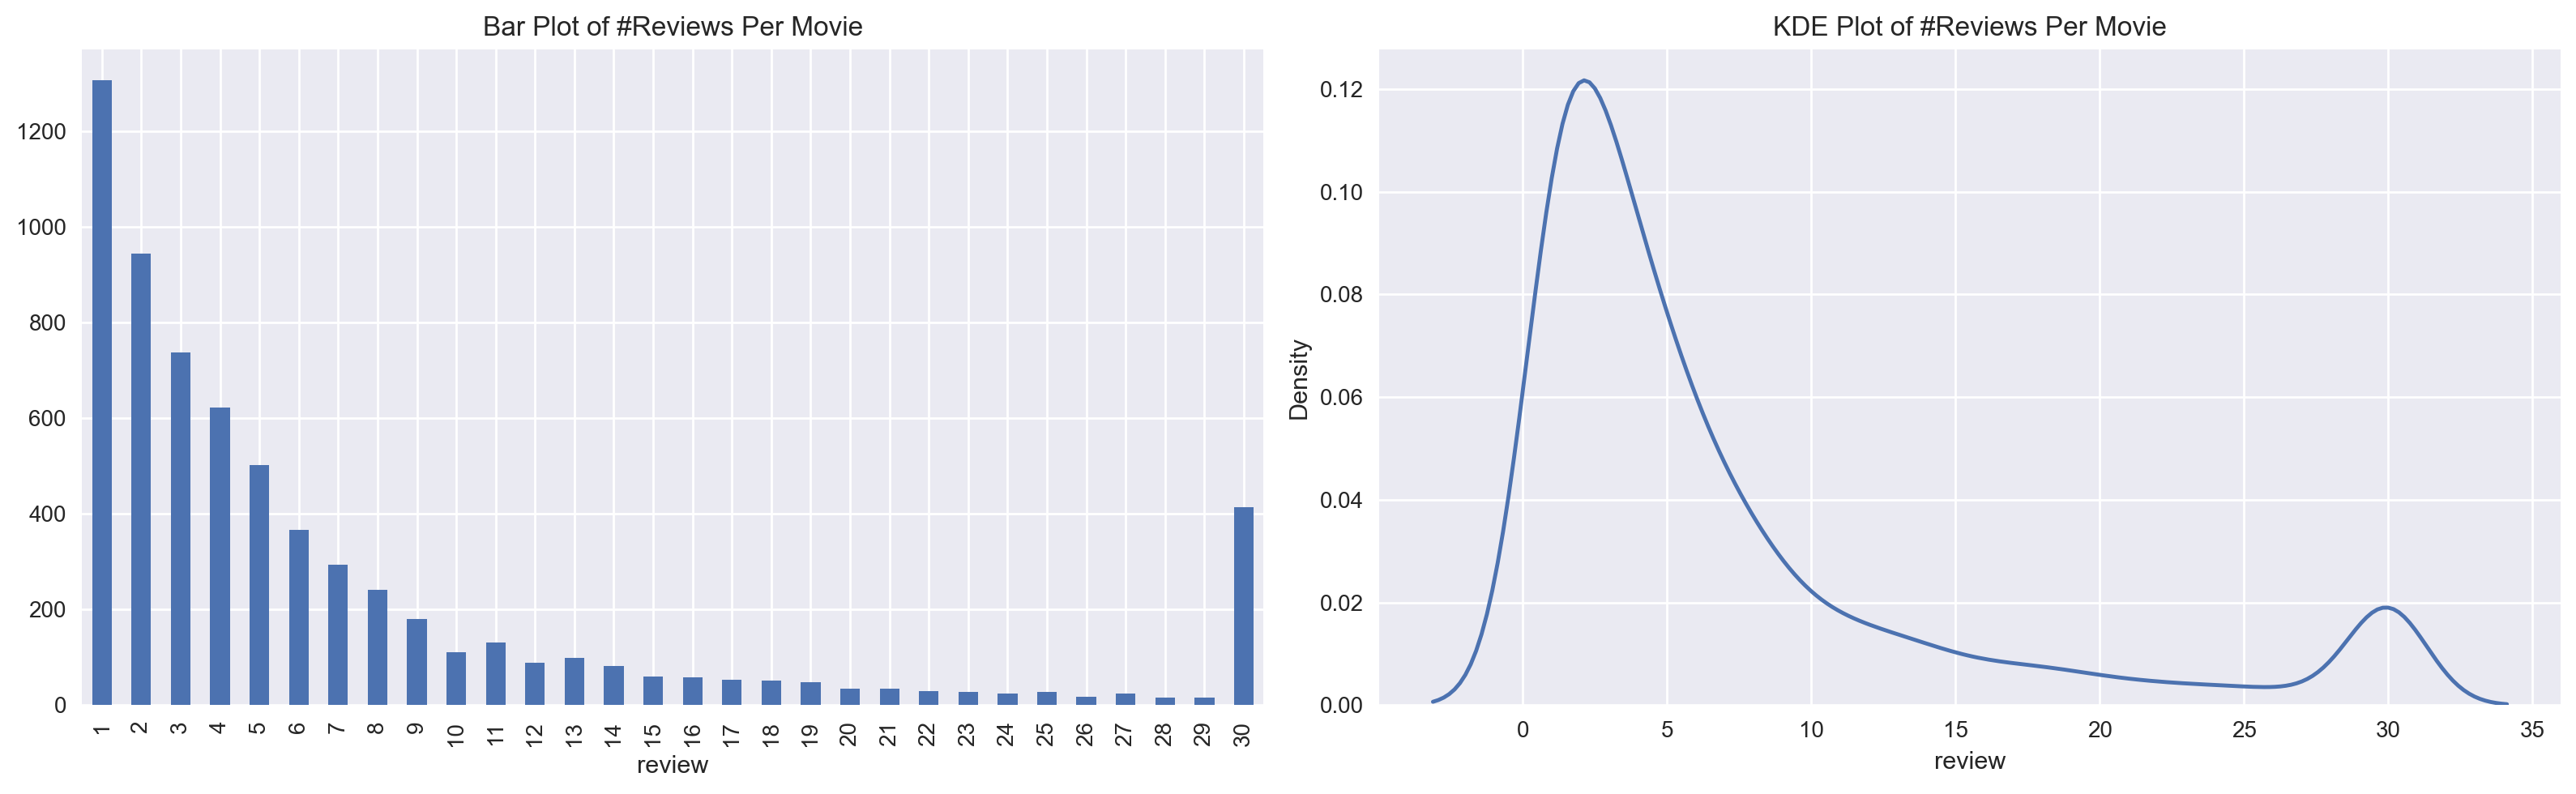

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

In [9]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23616
Name: count, dtype: int64

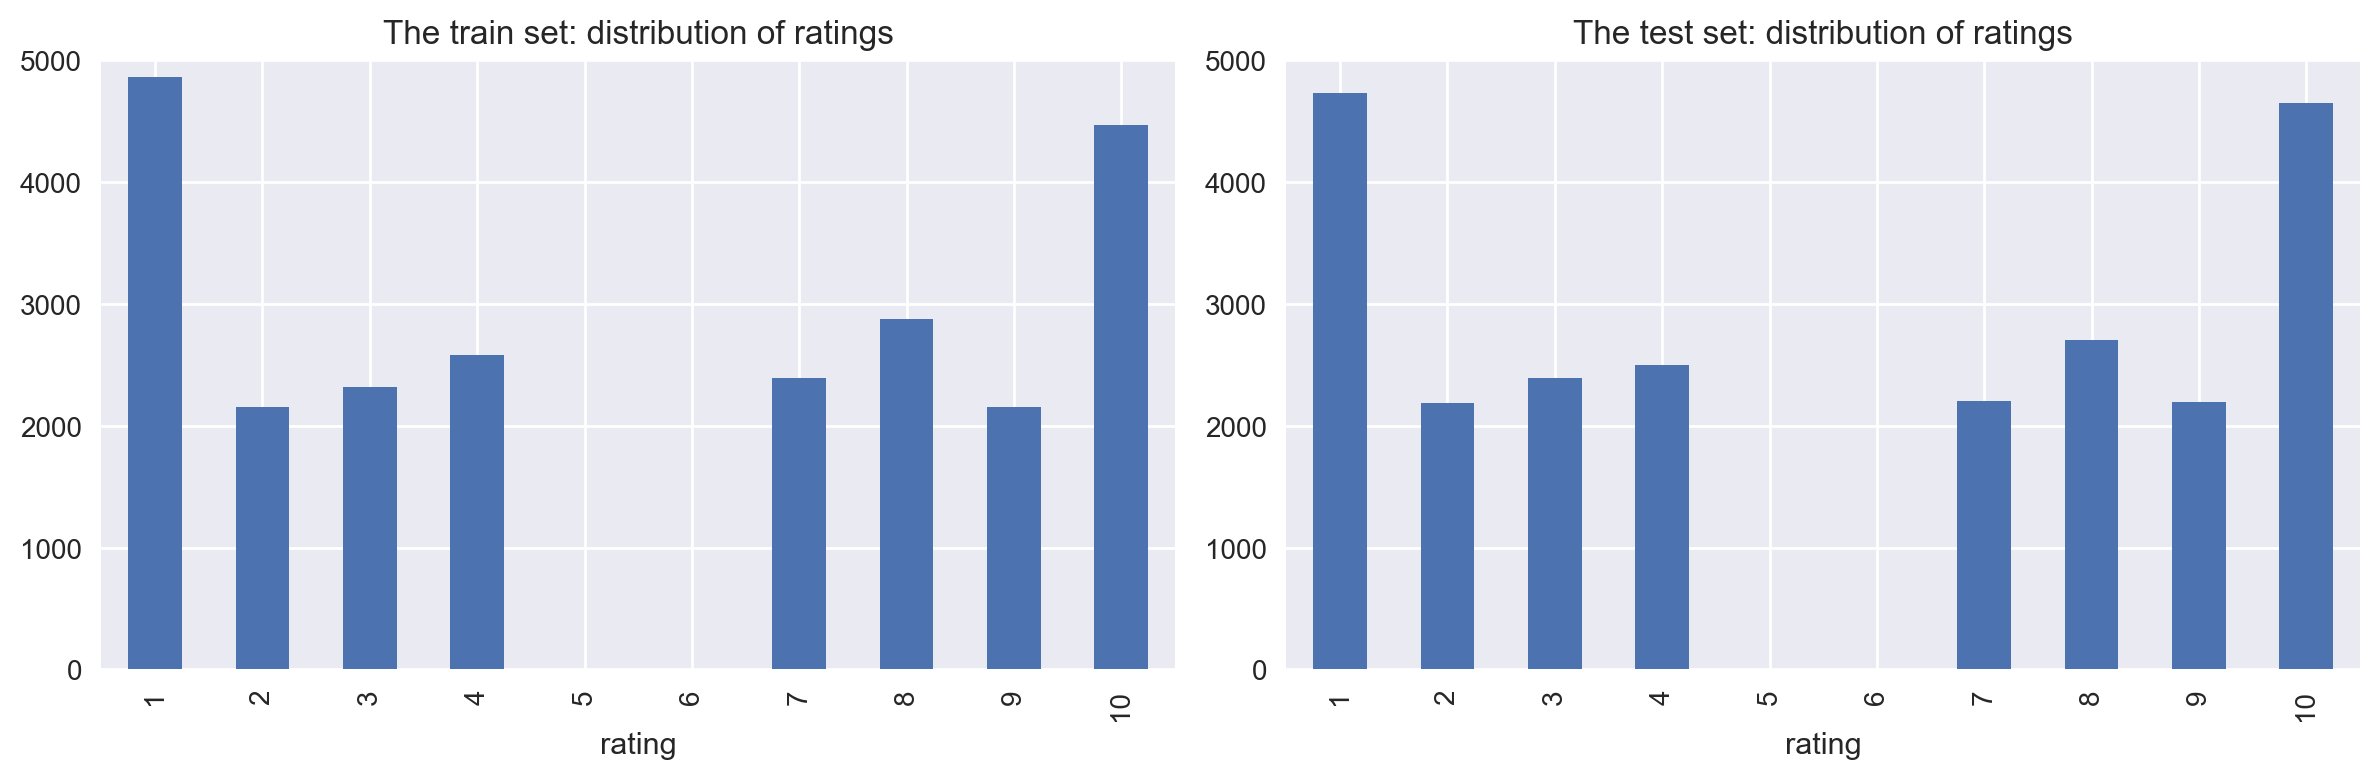

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

Distribution of negative and positive reviews over the years for two parts of the dataset

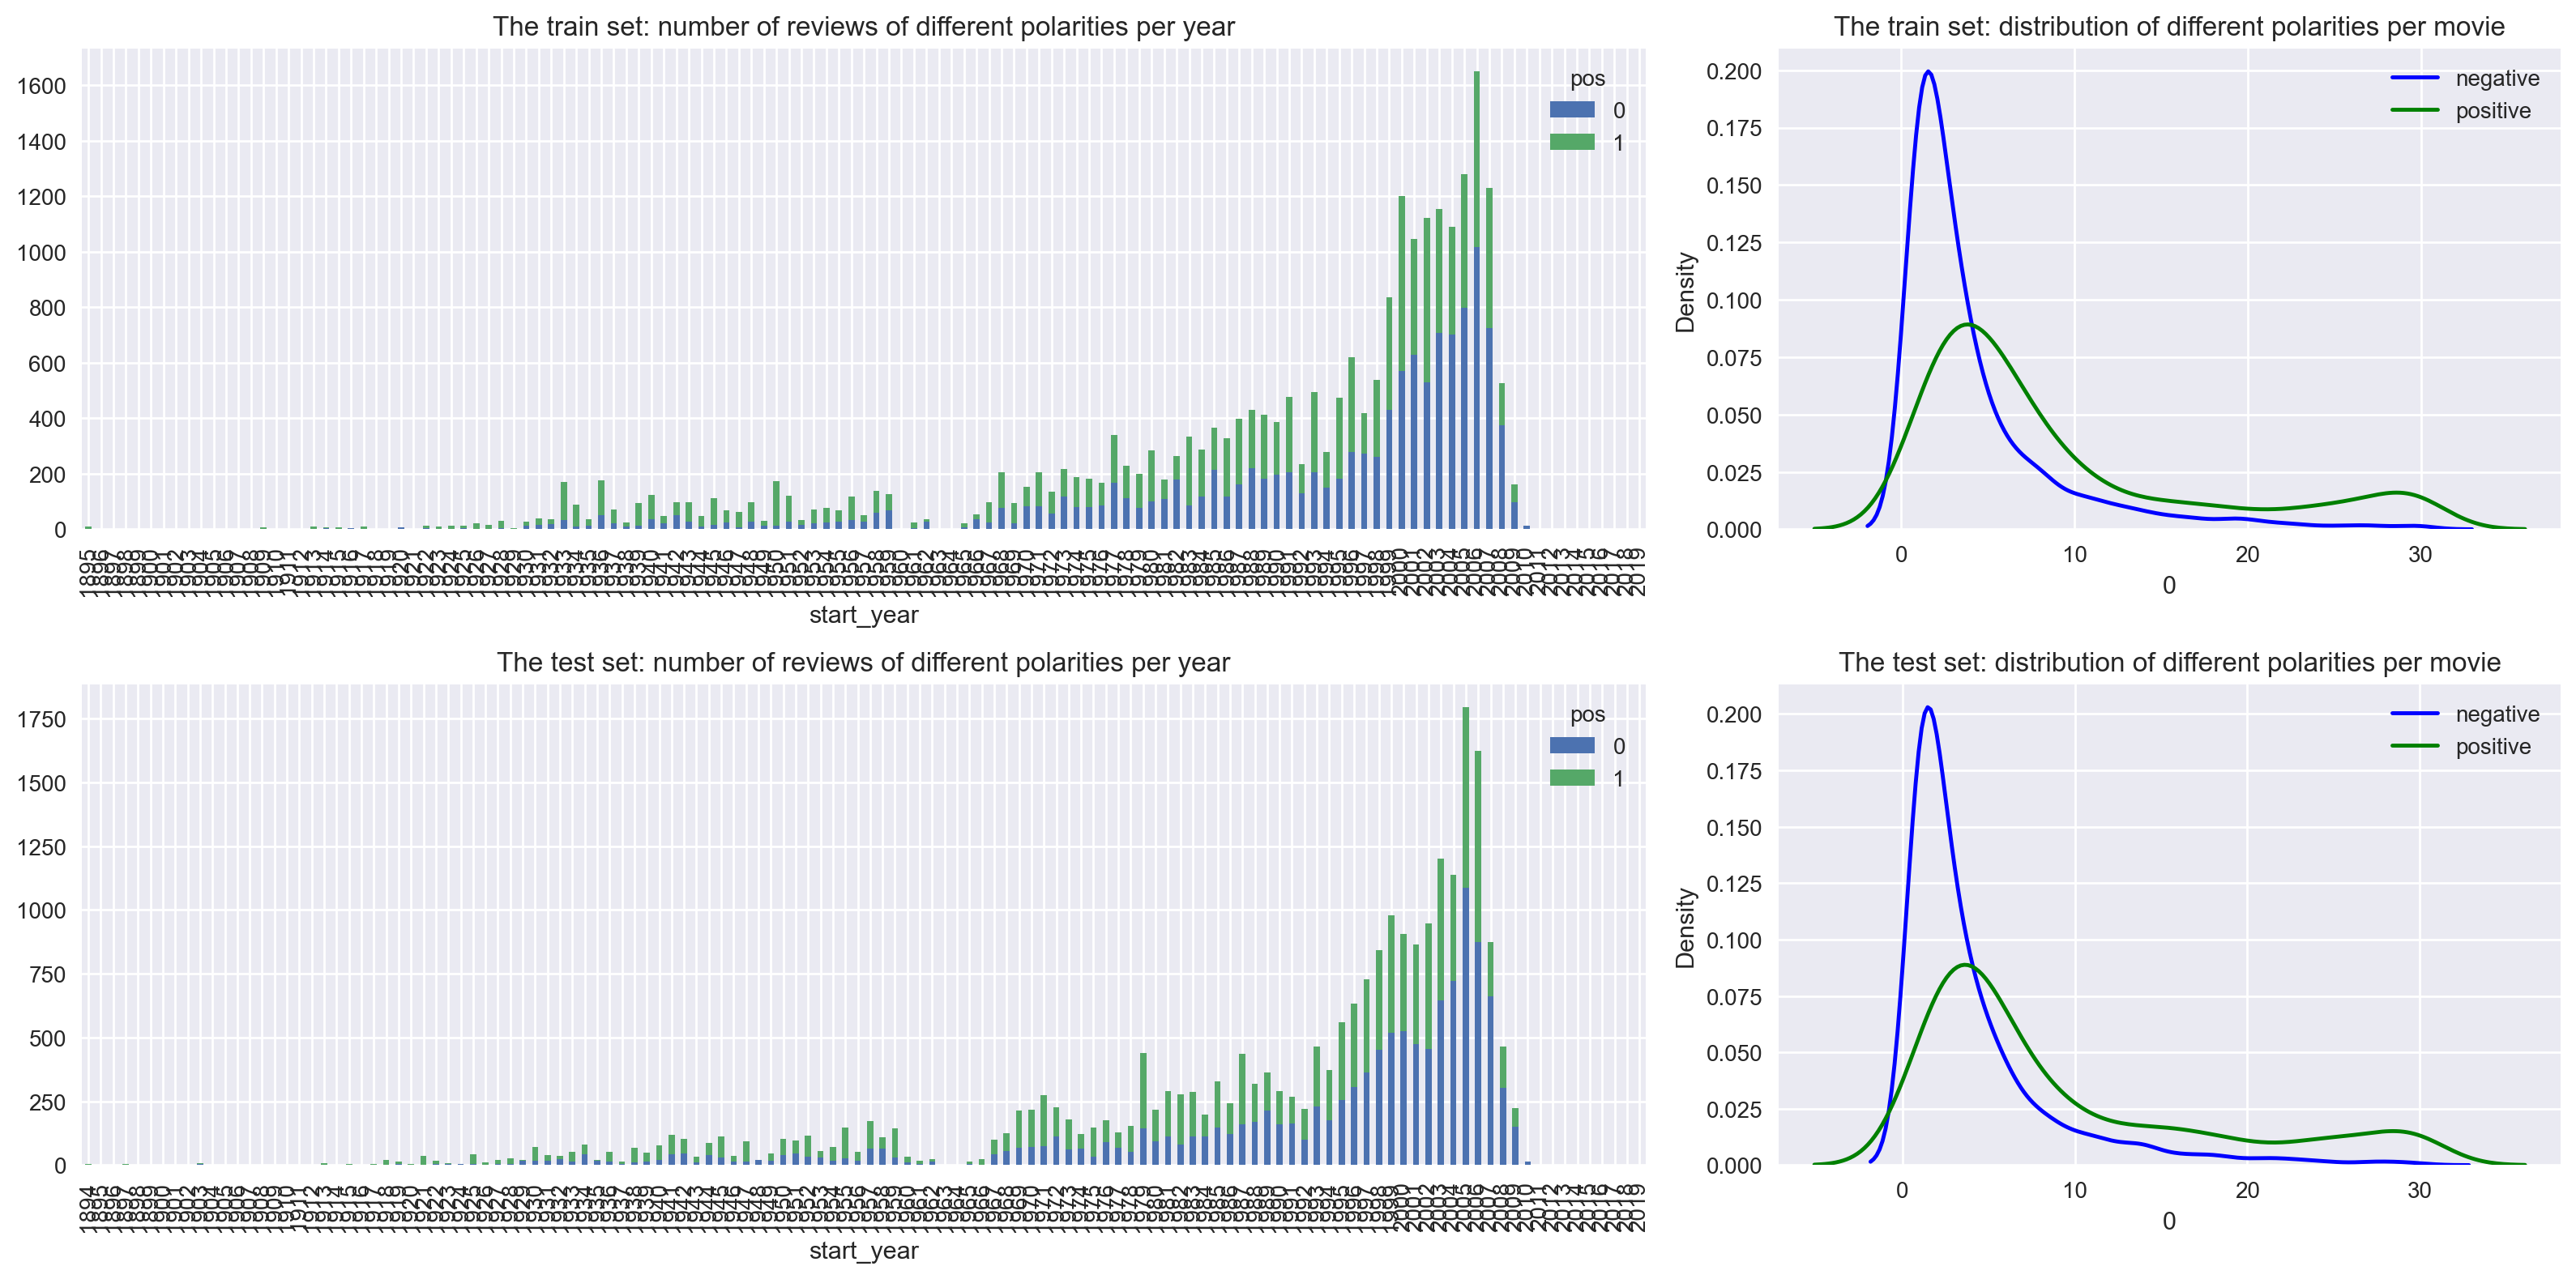

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

Similarities across train and test sets can also be seen in thier polarity ratings throughout the years. Reviews across train and test sets appear to be more positive then negative, following similar patterns through the years. This indicates a good balance in across the sets which makes them viable for training and testing models.

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [12]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [13]:
df_reviews['review_norm'] = df_reviews['review'].str.lower()

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [14]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_features = df_reviews_train['review_norm']
test_features = df_reviews_test['review_norm']

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Model Training and Evaluation

### Model 0 - Constant

In [15]:
dummy_clf = DummyClassifier(strategy='stratified')
dummy_clf.fit(train_features, train_target)

,strategy,'stratified'
,random_state,None
,constant,None


In [16]:
dummy_pred = dummy_clf.predict(test_features)
dummy_score = dummy_clf.score(test_target, dummy_pred)

In [17]:
print(f"dummy constant score: {dummy_score:.2f}")

dummy constant score: 0.50


### Model 1 - NLTK, TF-IDF and LR

In [18]:
# Tokenize and lemmatize text
def lemmatize_text(text):
    
    lemmatizer  = WordNetLemmatizer()

    processed_reviews = []
    for review in text:
        tokens = word_tokenize(review)
        lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]
        processed_reviews.append(' '.join(lemmas))
        
    return processed_reviews

In [19]:
train_features_lem = lemmatize_text(train_features)
test_features_lem = lemmatize_text(test_features)

In [20]:
# Set stop words and initialize model instance
stop_words = nltk_stopwords.words('english')
count_tf_idf_nltk = TfidfVectorizer(stop_words=stop_words)

In [21]:
# Vectorize reviews
tf_idf_train_features = count_tf_idf_nltk.fit_transform(train_features_lem)
tf_idf_test_features = count_tf_idf_nltk.transform(test_features_lem)

In [22]:
# Initiate and train LR model
model_LR_nltk = LogisticRegression()
model_LR_nltk.fit(tf_idf_train_features, train_target)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


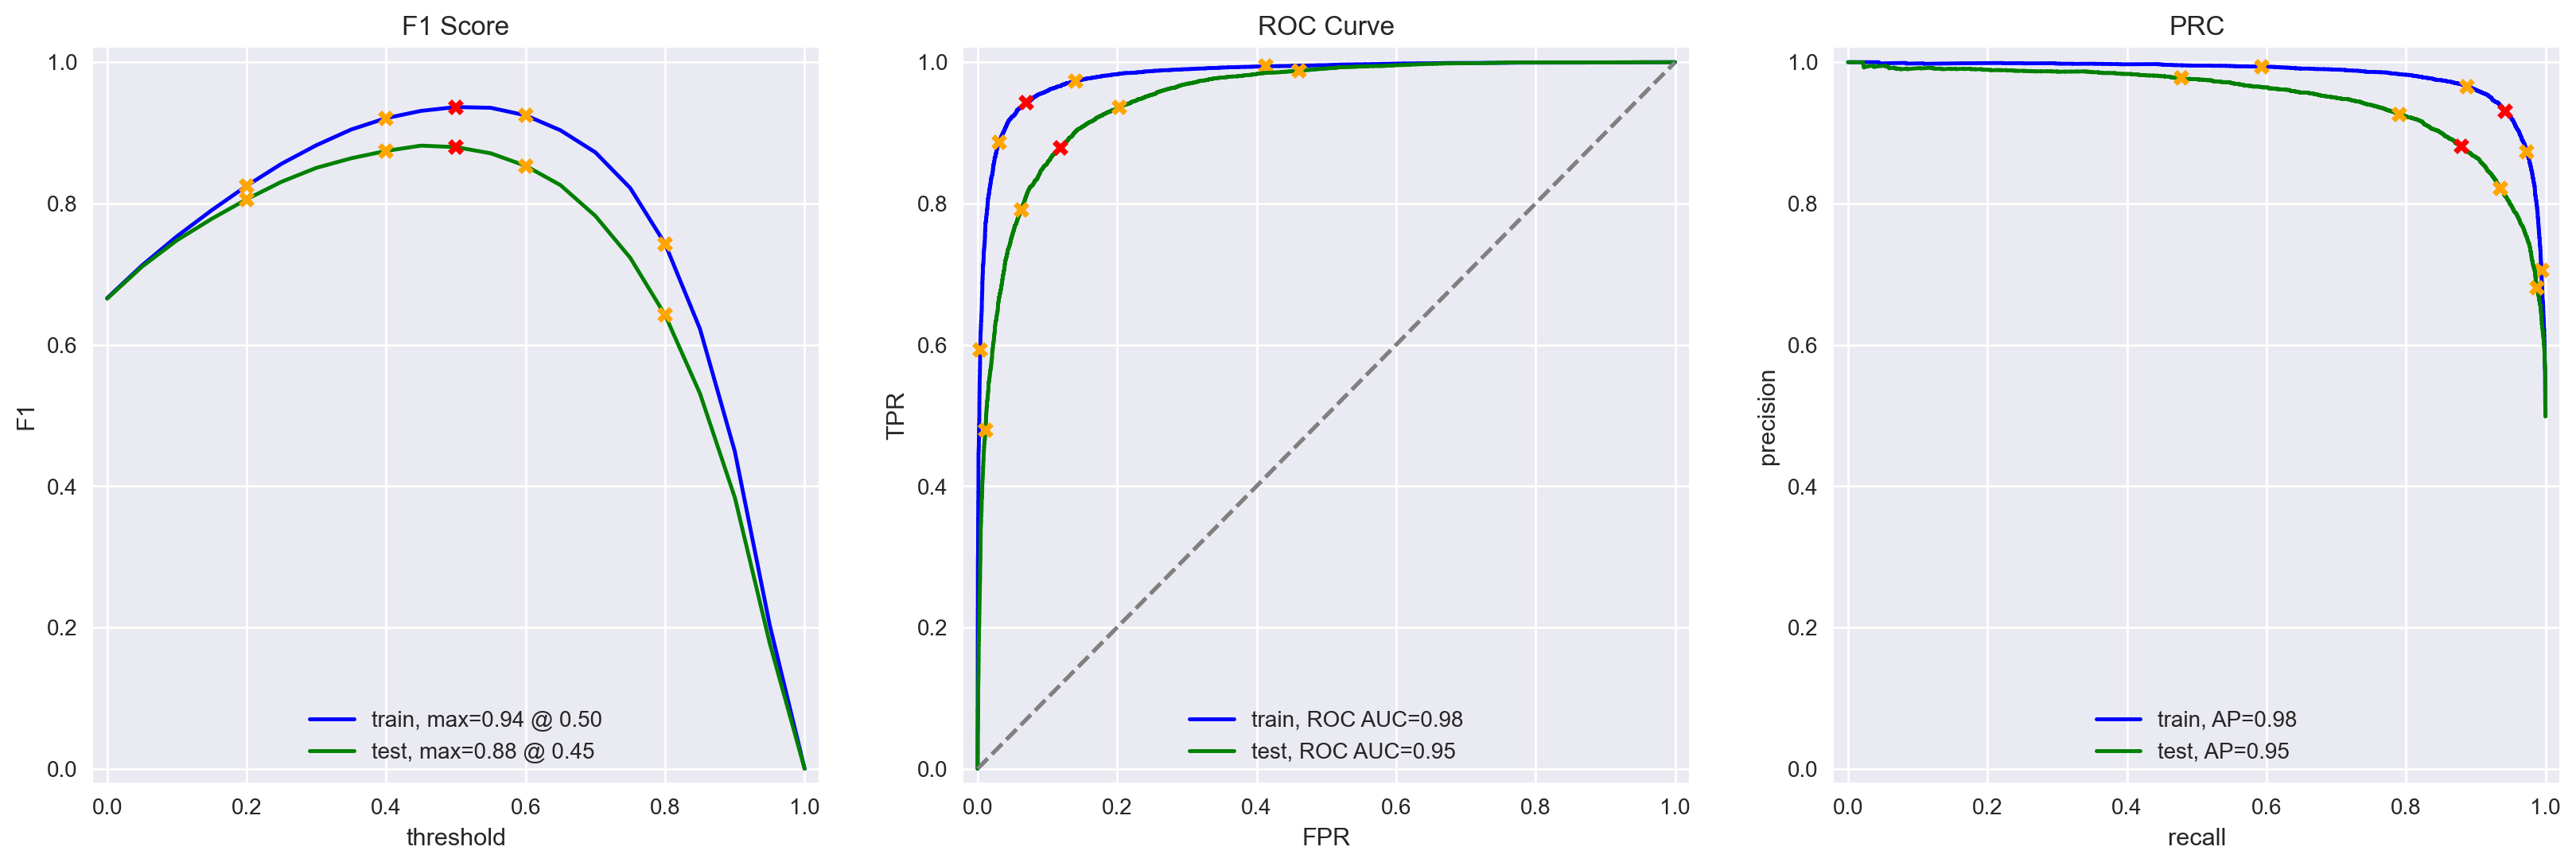

In [23]:
evaluate_nltk = evaluate_model(model_LR_nltk, tf_idf_train_features, train_target, tf_idf_test_features, test_target)

### Model 2 - spaCy, TF-IDF and LR

In [24]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [25]:
def text_preprocessing_spacy(text):

    reviews_lemma = []
    for review in text:
        doc = nlp(review)
        lemmas = [token.lemma_ for token in doc if not token.is_stop]
        reviews_lemma.append(' '.join(lemmas))

    return reviews_lemma

In [27]:
train_features_spacy = text_preprocessing_spacy(train_features)
test_features_spacy = text_preprocessing_spacy(test_features)

In [28]:
# Initialize model instance
count_tf_idf_spacy = TfidfVectorizer(stop_words=stop_words)

In [29]:
%%time
# Vectorize reviews
train_features_tfidf_spacy = count_tf_idf_spacy.fit_transform(train_features_spacy)
test_features_tfidf_spacy = count_tf_idf_spacy.transform(test_features_spacy)

CPU times: total: 3.48 s
Wall time: 3.52 s


In [30]:
# Initiate and train LR model
model_LR_spacy = LogisticRegression()
model_LR_spacy.fit(train_features_tfidf_spacy, train_target)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.94
ROC AUC    0.98  0.95


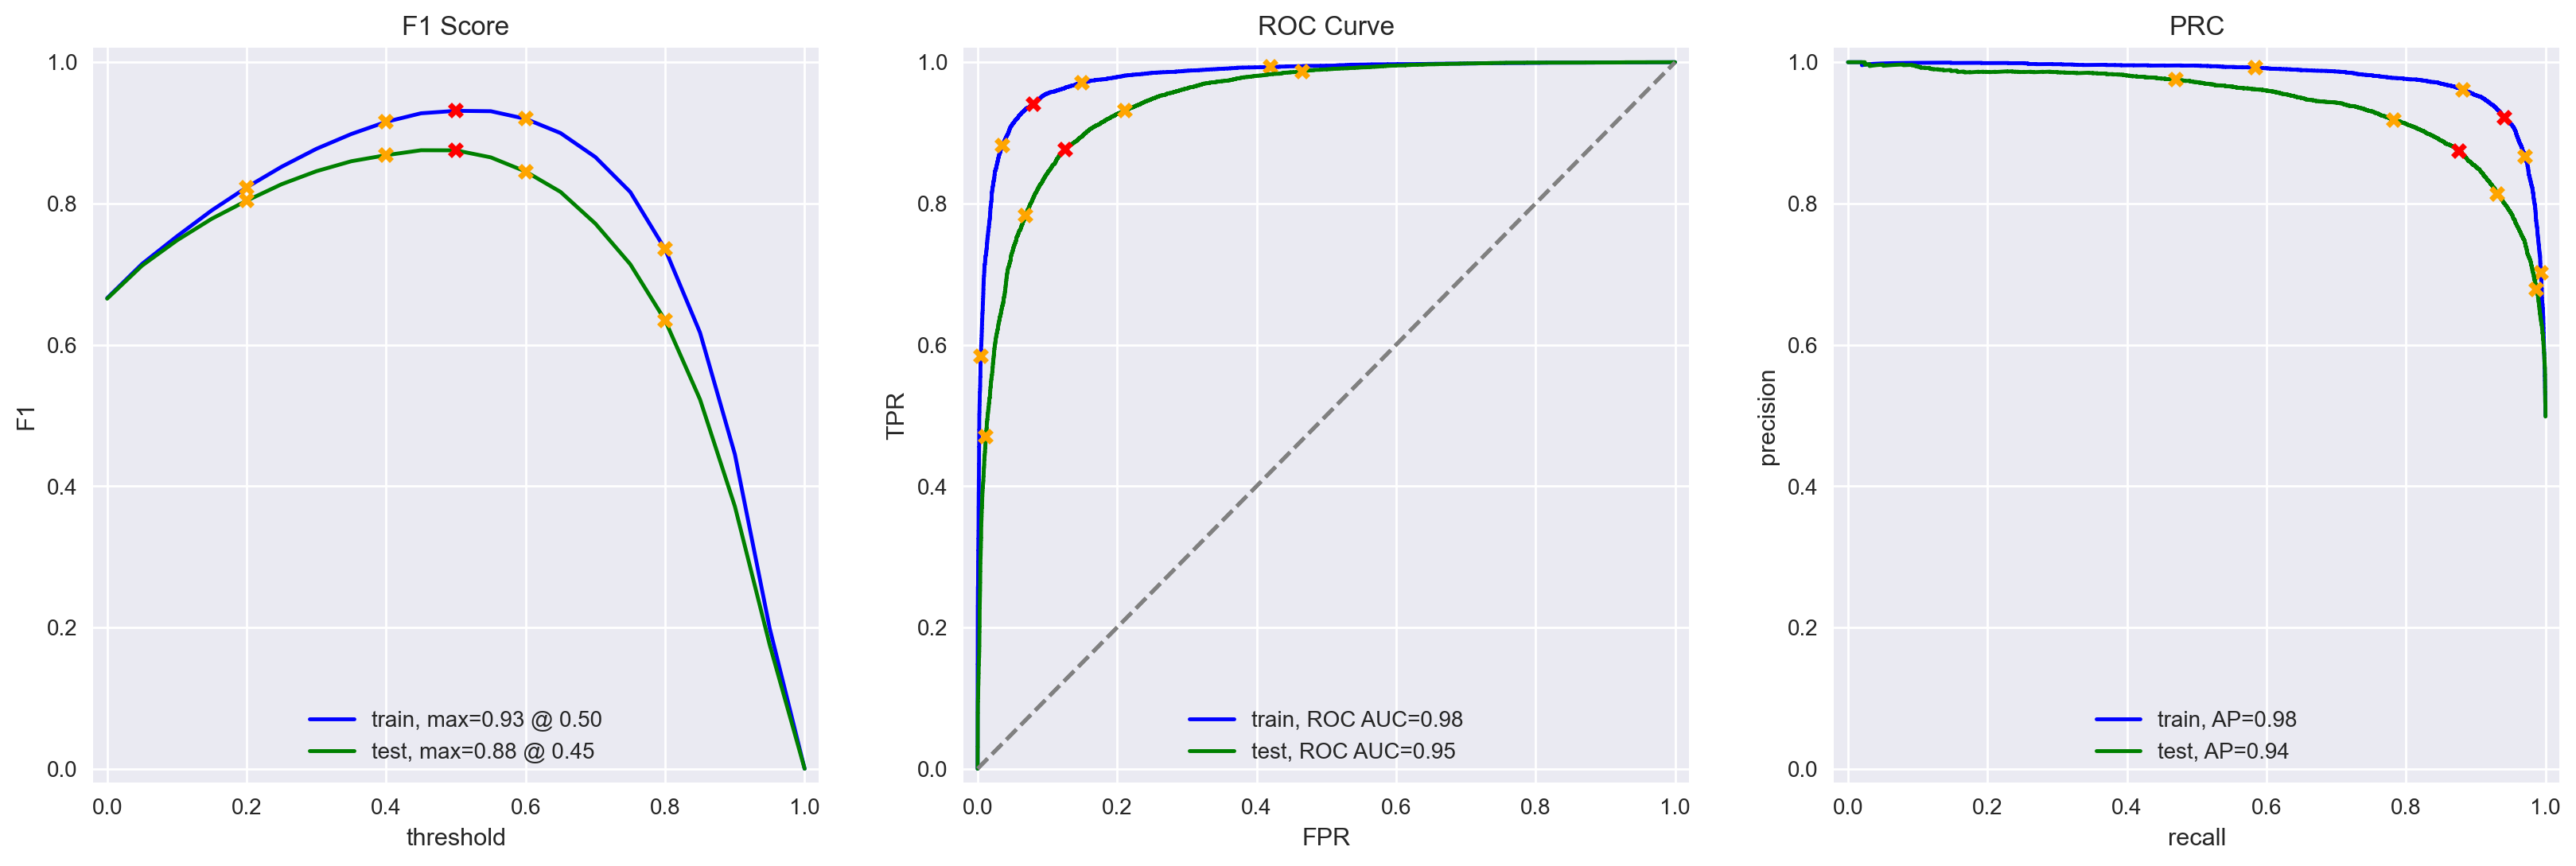

In [31]:
evaluate_spacy = evaluate_model(model_LR_spacy, train_features_tfidf_spacy, train_target, test_features_tfidf_spacy, test_target)

### Model 3 - spaCy, TF-IDF and LGBMClassifier

In [32]:
model_LGBM = LGBMClassifier(random_state=12345, n_estimators=200)
model_LGBM.fit(train_features_tfidf_spacy, train_target, callbacks=[log_evaluation(period=0)])

[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.725920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 436553
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 9415
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


          train  test
Accuracy   0.95  0.86
F1         0.95  0.86
APS        0.99  0.94
ROC AUC    0.99  0.94


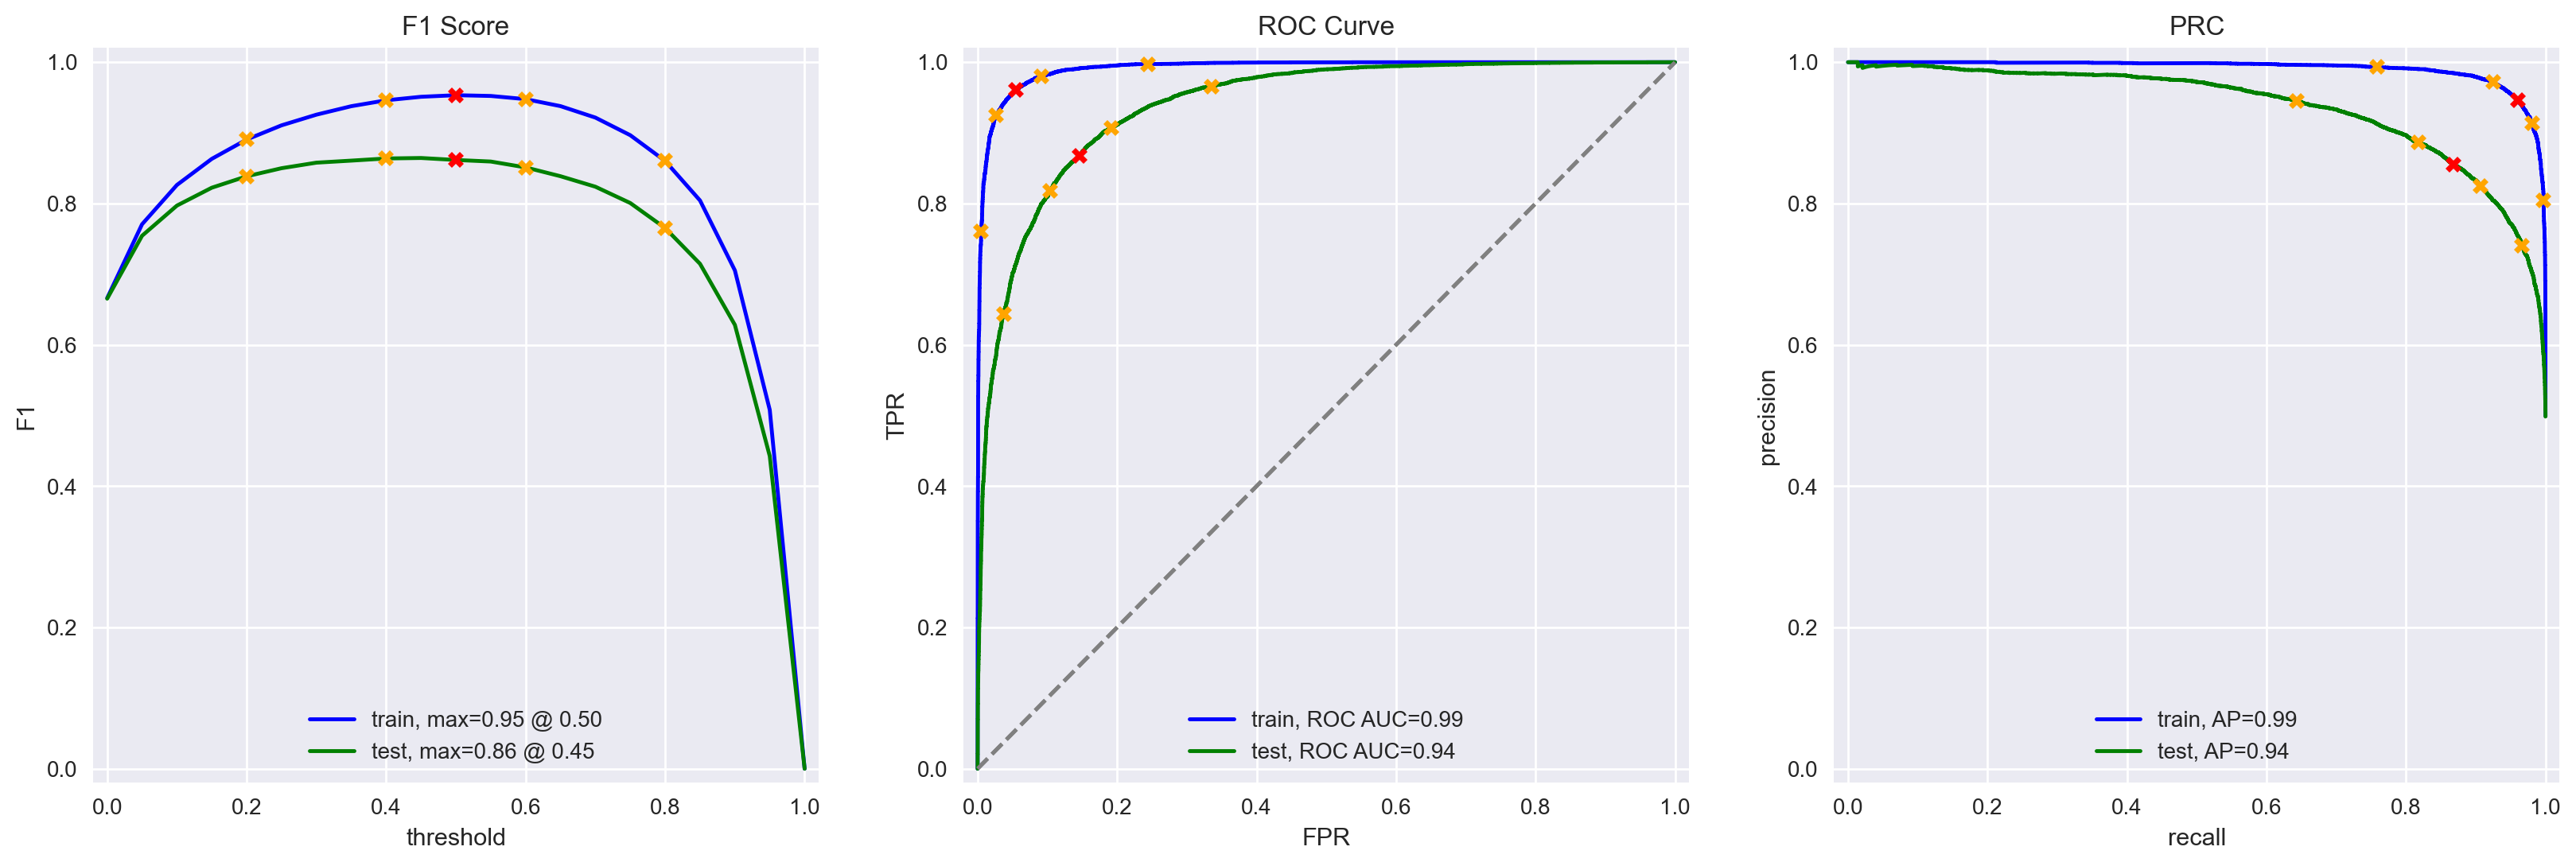

In [33]:
evaluate_LGBM = evaluate_model(model_LGBM, train_features_tfidf_spacy, train_target, test_features_tfidf_spacy, test_target)

###  Model 4 - BERT and LR

In [34]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [35]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # text to padded ids of tokens along with their attention masks
    
    for review in texts:
        ids = tokenizer.encode(
            review,
            add_special_tokens=True,
            truncation=True,
            max_length=max_length
        )
        padded = np.array(ids + [0] * (max_length - len(ids)))
        attention_mask = np.where(padded != 0, 1, 0)
        ids_list.append(padded)
        attention_mask_list.append(attention_mask)
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Using the {device} device.')
    
    # getting embeddings in batches

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

In [36]:
# %%time 
# # Create BERT embeddings for train and test features
# train_features_BERT = BERT_text_to_embeddings(train_features, force_device='cuda')
# test_features_BERT = BERT_text_to_embeddings(test_features, force_device='cuda')

In [37]:
# print(df_reviews_train['review_norm'].shape)
# print(train_features_BERT.shape)
# print(test_features_BERT.shape)
# print(train_target.shape)

In [38]:
# Save embeddings  
# np.savez_compressed('features_BERT.npz', train_features_BERT=train_features_BERT, test_features_BERT=test_features_BERT)

# Load embeddings
with np.load('features_BERT.npz') as data:
    train_features_BERT = data['train_features_BERT']
    test_features_BERT = data['test_features_BERT']

In [39]:
%%time
# Initiate and train LR model
model_LR_BERT = LogisticRegression()
model_LR_BERT.fit(train_features_BERT, train_target) 

CPU times: total: 4.08 s
Wall time: 1.26 s


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


          train  test
Accuracy   0.89  0.88
F1         0.89  0.88
APS        0.95  0.95
ROC AUC    0.95  0.95


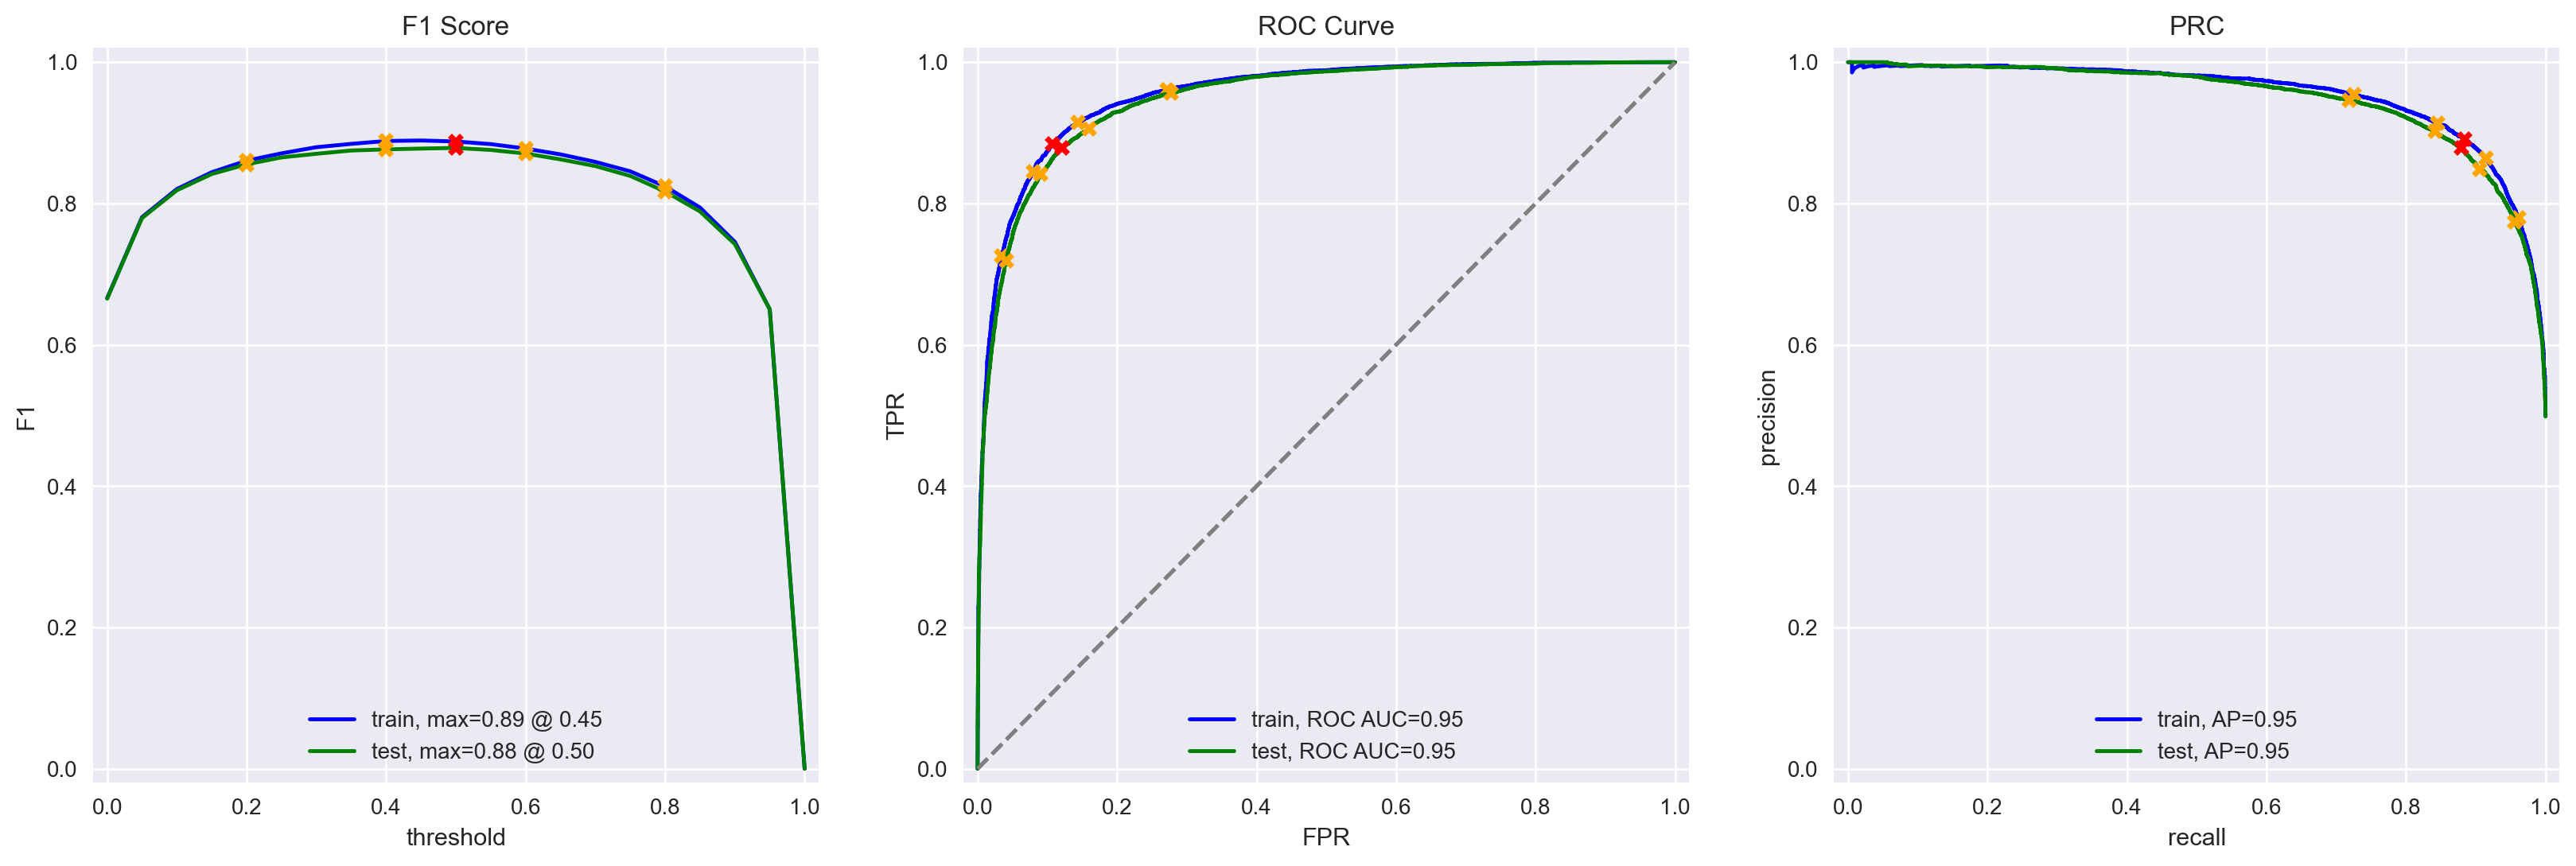

In [40]:
# Evaluate model
evaluate_BERT = evaluate_model(model_LR_BERT, train_features_BERT, train_target, test_features_BERT, test_target)

### Model 5 - BERT and LGBMClassifier

In [41]:
%%time
# Initiate and train LGBM 
model_LGBM_BERT = LGBMClassifier(random_state=12345, n_estimators=200)
model_LGBM_BERT.fit(train_features_BERT, train_target, callbacks=[log_evaluation(period=0)])

[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.110834 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353
CPU times: total: 41.5 s
Wall time: 11.5 s


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


          train  test
Accuracy   0.98  0.86
F1         0.98  0.86
APS        1.00  0.94
ROC AUC    1.00  0.93


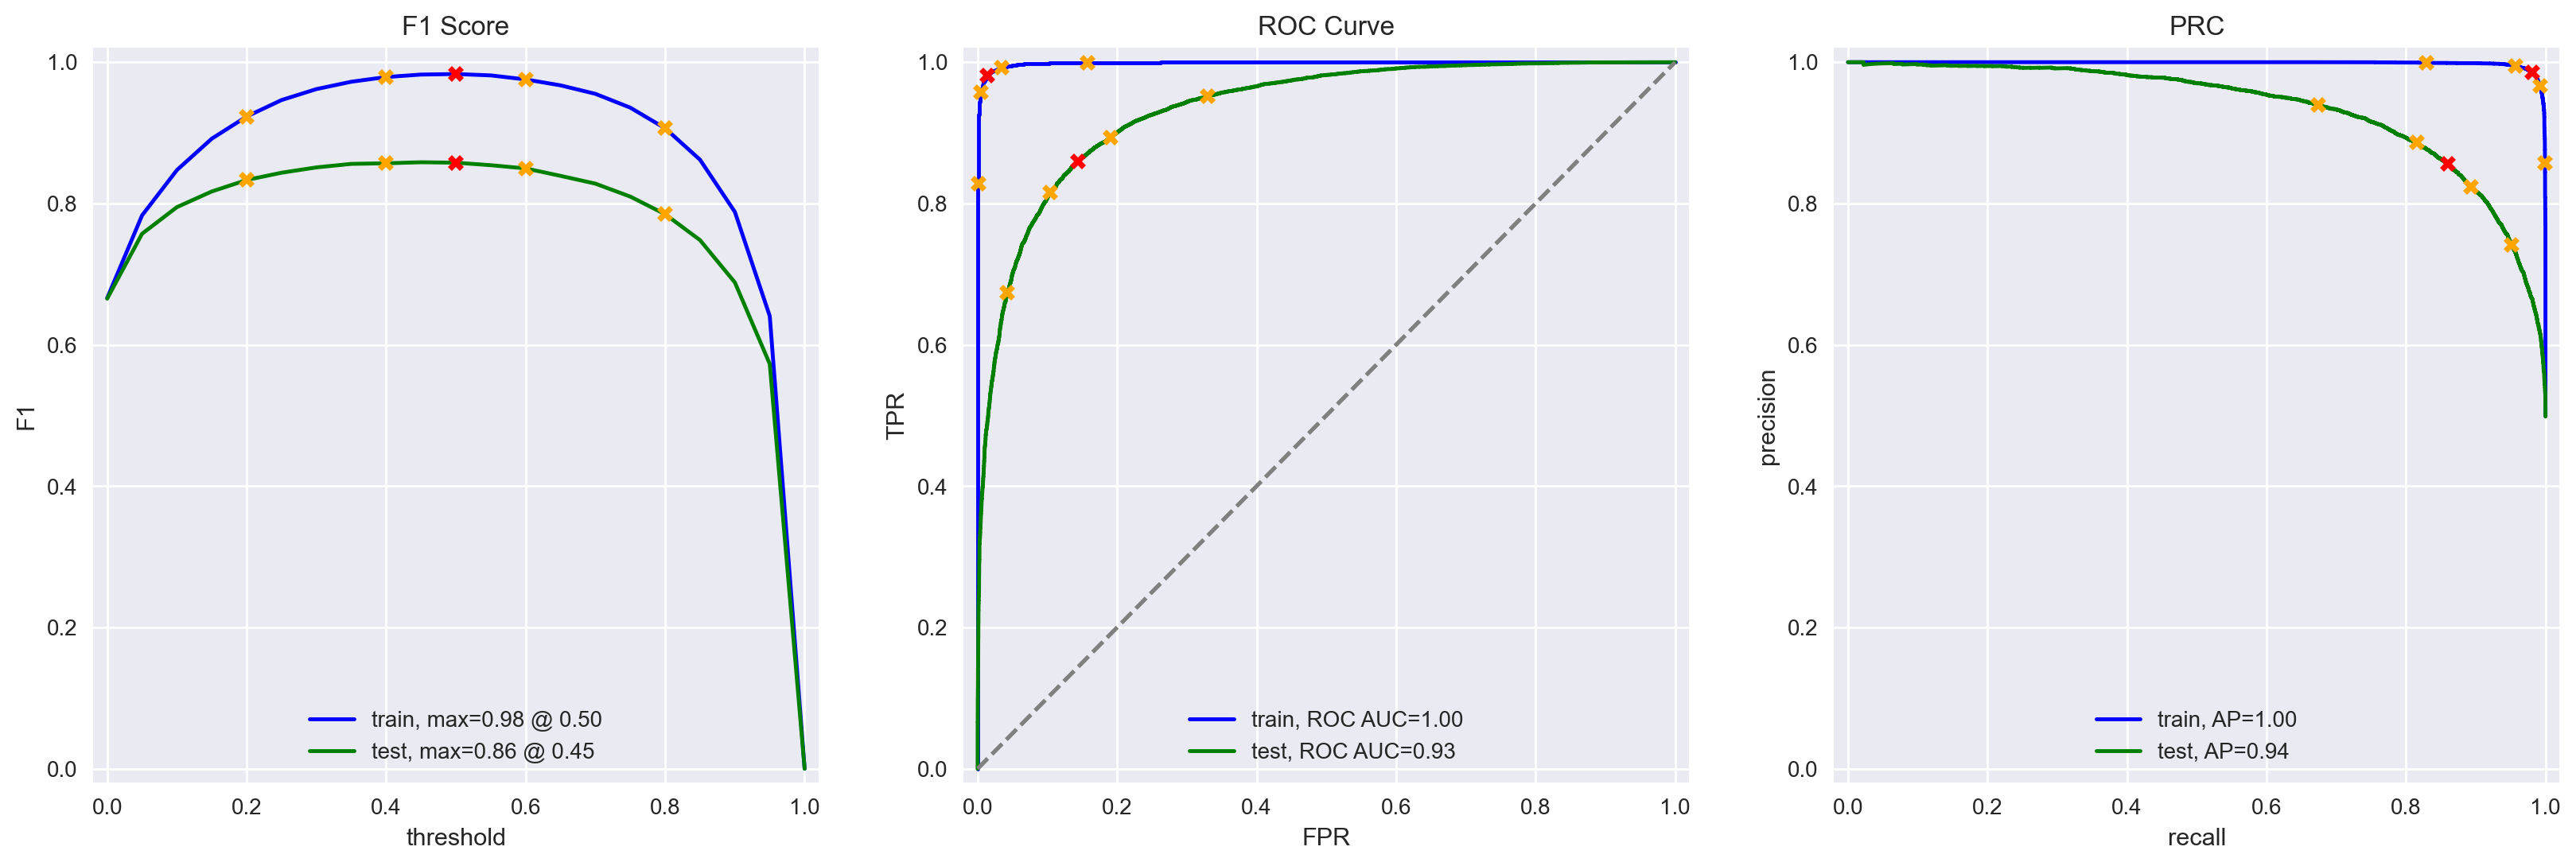

In [42]:
evaluate_BERT = evaluate_model(model_LGBM_BERT, train_features_BERT, train_target, test_features_BERT, test_target)

## Sample review prediction probabilities

In [43]:
# Feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].str.lower()

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.","i did not simply like it, not my kind of movie."
1,"Well, I was bored and felt asleep in the middl...","well, i was bored and felt asleep in the middl..."
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn't expect the reboot to be so good! writ...
5,"The movie had its upsides and downsides, but I...","the movie had its upsides and downsides, but i..."
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy. not a singl...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move & i real...


### Model NTLK-LR

In [44]:
texts = my_reviews['review_norm']

my_reviews_pred_prob_nltk = model_LR_nltk.predict_proba(count_tf_idf_nltk.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_nltk[i]:.2f}:  {review}')

0.16:  i did not simply like it, not my kind of movie.
0.17:  well, i was bored and felt asleep in the middle of the movie.
0.57:  i was really fascinated with the movie
0.16:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.39:  i didn't expect the reboot to be so good! writers really cared about the source material
0.49:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.12:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
0.89:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


### Model spaCY-LR

In [46]:
texts = my_reviews['review_norm']
spacy_texts = text_preprocessing_spacy(texts)

my_reviews_pred_prob_spacy = model_LR_spacy.predict_proba(count_tf_idf_spacy.transform(spacy_texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_spacy[i]:.2f}:  {review}')

0.16:  i did not simply like it, not my kind of movie.
0.09:  well, i was bored and felt asleep in the middle of the movie.
0.61:  i was really fascinated with the movie
0.17:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.24:  i didn't expect the reboot to be so good! writers really cared about the source material
0.39:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.02:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
0.90:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


### Model spaCY-TF-IDF-LGBM

In [48]:
texts = my_reviews['review_norm']
spacy_texts = text_preprocessing_spacy(texts)

my_reviews_pred_prob_spacy = model_LGBM.predict_proba(count_tf_idf_spacy.transform(spacy_texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_spacy[i]:.2f}:  {review}')

0.52:  i did not simply like it, not my kind of movie.
0.34:  well, i was bored and felt asleep in the middle of the movie.
0.55:  i was really fascinated with the movie
0.30:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.59:  i didn't expect the reboot to be so good! writers really cared about the source material
0.49:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.20:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
0.83:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


### Model BERT-LR

In [49]:
texts = my_reviews['review_norm']
my_reviews_features_BERT = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob_BERT = model_LR_BERT.predict_proba(my_reviews_features_BERT)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_BERT[i]:.2f}:  {review}')

0.50:  i did not simply like it, not my kind of movie.
0.04:  well, i was bored and felt asleep in the middle of the movie.
0.87:  i was really fascinated with the movie
0.01:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.10:  i didn't expect the reboot to be so good! writers really cared about the source material
0.74:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.01:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
1.00:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


## Conclusions

### Findings

Project shows both logistic regression and LGBM models to be effective for sentiment analysis, with some key takeaways to note:

| Model | Accuracy | F1 | Presicion | ROC AUC |
| --- | --- | --- | --- | --- | 
| NLTK, TF-IDF and LR | 0.88 | 0.88 | 0.95 | 0.95 |
| spaCy, TF-IDF and LR | 0.88 | 0.88 | 0.94 | 0.95 |
| spaCy, TF-IDF and LGBMClassifier | 0.86 | 0.86 | 0.94 | 0.94 |
| BERT and Logistic Regression | 0.88 | 0.88 | 0.95 | 0.95 |
| BERT and LGBMClassifier | 0.86 | 0.86 | 0.94 | 0.93 |

Functionality of models seems to be confirmed when comparing F1 score with review probabilities. As most models appear to predict low probabilities for either one or two reviews that could potentialy be positive. This corelates to the diferent models F1 score of around 0.80.
Probaility prediction versus bipolar sentiment prediction, appears to be better suitied for classifiying movie reviews. This offers greater sentiment distribution not available in bipolar classification. In this case, one could argue model using LGBM from probability prediction is best model. However F1 score still puts logistic regression for bipolar classification higher.

### Recommendations

* To utilize BERT preprocessing and train using logistic regression, this appears to perform better than other models.
* Sentiment Analysis would provide a more effective way of categorizing film review rather than bipolar (negative, postive) classification.